# Create Geometries
Geometries are the fundamental building blocks of vector data and describe the spatial shape of features such as infrastructure elements or boundaries.
This examples shows how to create basic vector geometries in GeoKit and how coordinate reference systems affect their interpretation.

Geokit can create:
 
1. Point
2. MultiPoint
3. LineString
4. MultiLineString
5. Polygon
6. MultiPolygon

Vectors are created from coordinates. Before creating a vector, you need to choose the coordinate system in which those coordinates are defined.

In these examples, we use two systems:

- **Geographic coordinates** in **EPSG:4326** (longitude/latitude)  
- **Projected coordinates** in a **local Lambert Azimuthal Equal-Area (LAEA) projection** centered on Aachen

The notebook `_1_how_to_set_coordinate_systems.ipynb` shows how to specify other coordinate systems.

If you are new to geospatial coordinate systems, you can learn more here:  
https://en.wikipedia.org/wiki/Spatial_reference_system



**Import required packages**

GeoKit is imported which provides the required classes and functions

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import geokit as gk
import geokit.core.geom
import geokit.core.srs

**1. Point: Create 2-Dimensional Point**

In [ ]:
# Create individual point geometries using either a coordinate tuple or two separate coordinate arguments.

aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)
# Tuple representing the coordinates of your points (in meters)
point_1 = (0, 0)
point_2 = (40000, 0)
point_3 = (40000, 30000)

# Create point geometry from tuple
aachen_pt_1_from_tuple = geokit.core.geom.point(point_1, srs=aachen_centered_srs)
aachen_pt_2_from_tuple = geokit.core.geom.point(point_2, srs=aachen_centered_srs)
aachen_pt_3_from_tuple = geokit.core.geom.point(point_3, srs=aachen_centered_srs)

print(type(aachen_pt_1_from_tuple))

# Create point geometry from separate x and y values (in longitude and latitude)
aachen_pt_4_from_two_arguments = geokit.core.geom.point(6.373, 51.225, srs=4326)
aachen_pt_5_from_two_arguments = geokit.core.geom.point(6.083, 51.045, srs=4326)


# Define a projection for the Aachen area
aachen_centered_srs = geokit.core.srs.centeredLAEA(6.083, 50.775)

# Transform the points to the defined projection
aachen_pt_4_from_two_arguments = geokit.core.geom.transform(aachen_pt_4_from_two_arguments, aachen_centered_srs)
aachen_pt_5_from_two_arguments = geokit.core.geom.transform(aachen_pt_5_from_two_arguments, aachen_centered_srs)

<class 'osgeo.ogr.Geometry'>


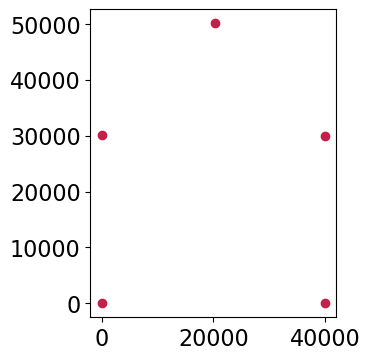

In [ ]:
# Plot the points
axh = gk.drawGeoms(
    geoms=[
        aachen_pt_1_from_tuple,
        aachen_pt_2_from_tuple,
        aachen_pt_3_from_tuple,
        aachen_pt_4_from_two_arguments,
        aachen_pt_5_from_two_arguments,
    ],
    figsize=(4, 4),
    srs=aachen_centered_srs,
)

**2. LineString: Create Lines**

In [ ]:
# Create a LineString geometry from a list of coordinate tuples.

# Define a projection for Aachen area
aachen_centered_srs = geokit.core.srs.centeredLAEA(6.083, 50.775)

# Create a linestring geometry using a list of xy-coordinate tuples
aachen_line = geokit.core.geom.line(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),
    ],
    srs=aachen_centered_srs,
)

print(type(aachen_line))

<class 'osgeo.ogr.Geometry'>


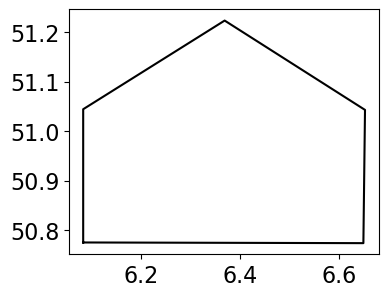

In [ ]:
# Plot the line geometry
axh = gk.drawGeoms([aachen_line], figsize=(4, 4))

**3. MultiLineString: Create MultiLines**

In [ ]:
# Create a MultiLineString geometry from a list of coordinate tuples.

# Define a projection for Aachen area
aachen_centered_srs = geokit.core.srs.centeredLAEA(6.083, 50.775)

# Create a linestring geometry using a list of xy-coordinate tuples
aachen_line_1 = geokit.core.geom.line(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),
    ],
    srs=aachen_centered_srs,
)

# Create a linestring geometry using a list of xy-coordinate tuples
aachen_line_2 = geokit.core.geom.line(
    [
        (40000, 0),
        (80000, 0),
        (80000, 30000),
        (60000, 50000),
        (40000, 30000),
    ],
    srs=aachen_centered_srs,
)

lines = [aachen_line_1, aachen_line_2]
multi_line = geokit.core.geom.flatten(lines)

print(type(multi_line))

<class 'osgeo.ogr.Geometry'>


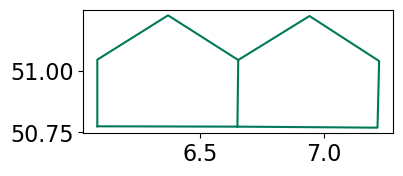

In [ ]:
# Plot the line geometry
axh = gk.drawGeoms([multi_line], figsize=(4, 4))

**4. Polygon: Create Polygon**

In [ ]:
# Create a Polygon geometry from a list of coordinate tuples.

# Define a projection for the Aachen area
aachen_centered_srs = geokit.core.srs.centeredLAEA(6.083, 50.775)

aachen_polygon = geokit.core.geom.polygon(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),
    ],
    srs=4326,
)

print(type(aachen_polygon))
asd = aachen_polygon.GetSpatialReference()
asd.ExportToPrettyWkt()

<class 'osgeo.ogr.Geometry'>


'GEOGCS["WGS 84",\n    DATUM["WGS_1984",\n        SPHEROID["WGS 84",6378137,298.257223563,\n            AUTHORITY["EPSG","7030"]],\n        AUTHORITY["EPSG","6326"]],\n    PRIMEM["Greenwich",0,\n        AUTHORITY["EPSG","8901"]],\n    UNIT["degree",0.0174532925199433,\n        AUTHORITY["EPSG","9122"]],\n    AXIS["Latitude",NORTH],\n    AXIS["Longitude",EAST],\n    AUTHORITY["EPSG","4326"]]'

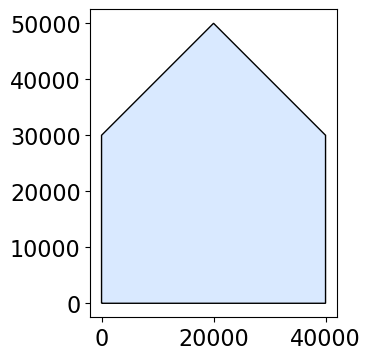

In [ ]:
axh = gk.drawGeoms([aachen_polygon], figsize=(4, 4))

**5. MultiPolygon: Create MultiPolygon**

In [ ]:
# Create a Polygon geometry from a list of coordinate tuples.

# Define a projection for the Aachen area
aachen_centered_srs = geokit.core.srs.centeredLAEA(6.083, 50.775)

# Create 2 polygons from an ordered list of xy-coordinate tuples
aachen_polygon_1 = geokit.core.geom.polygon(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),
    ],
    srs=aachen_centered_srs,
)

aachen_polygon_2 = geokit.core.geom.polygon(
    [
        (40000, 0),
        (80000, 0),
        (80000, 30000),
        (60000, 50000),
        (40000, 30000),
        (40000, 0),
    ],
    srs=aachen_centered_srs,
)

# combine polygons into a multipolygon
polys = [aachen_polygon_1, aachen_polygon_2]
multi_poly = geokit.core.geom.flatten(polys)

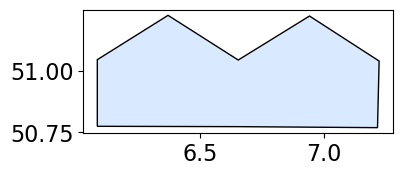

In [ ]:
axh = gk.drawGeoms([multi_poly], figsize=(4, 4))